# Section 4 — Special Topics in Machine Learning

Imbalanced classification, convolutional neural networks (CNNs), and fairness in machine learning — applied hands-on with the techniques from the slides.

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger (8–9 June 2026, Munich).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/ml-genai-actuarial-practice/blob/main/notebooks/04_special_topics_ml/04_special_topics_ml.ipynb)

Repository: [simonhatzesberger/ml-genai-actuarial-practice](https://github.com/simonhatzesberger/ml-genai-actuarial-practice) — Code under the [MIT License](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).

This notebook completes Act I of the seminar with three "special topics" that show up in almost every real actuarial ML project:

- **Imbalanced classification** — rare claims, fraud, lapse, large-loss flags. The naive metrics break and the standard recipes need a re-think.
- **CNNs on image data** — when the input is not a table of features but a grid of pixels (damage photos, satellite tiles, medical scans).
- **Fairness in ML** — how to measure group-level bias, what trade-offs exist between fairness criteria, and what we can do about it under the EU AI Act and GDPR.

Each section is self-contained: motivation, concept, a small worked example, an exercise, and a short recap that maps back to the learning goal.

## Contents

- [Learning objectives](#learning-objectives)
- [Setup](#setup)
- [1. Imbalanced classification](#1-imbalanced-classification)
- [2. CNNs on image data](#2-cnns-on-image-data)
- [3. Fairness in machine learning](#3-fairness-in-machine-learning)
- [Summary](#summary)
- [Next steps](#next-steps)
- [References](#references)

## Learning objectives

By the end of this notebook you will be able to:

- recognise when class imbalance breaks the usual evaluation pipeline, and pick *appropriate* metrics (PR-AUC, F1, MCC, balanced accuracy) and *appropriate* fixes (resampling such as SMOTE, class weights, threshold tuning);
- explain how a CNN turns a pixel grid into a class probability via convolution, pooling, and parameter sharing, and train a small CNN on image data on a laptop CPU;
- apply an Explainable-AI technique — **Grad-CAM** — to a trained CNN to see *where in the image* the model looked;
- audit a tabular classifier for group fairness with **Fairlearn**'s `MetricFrame`, measure demographic parity / equalized odds / calibration within groups, and recognise the **Chouldechova–Kleinberg impossibility result**;
- apply one mitigation technique from each of the three families (pre-, in-, and post-processing) and read the fairness-accuracy trade-off honestly.

## Setup

The cell below detects whether you are on Google Colab. On Colab it installs the section's pinned dependencies. Locally it assumes you have run `pip install -r notebooks/04_special_topics_ml/requirements.txt` inside your virtual environment. Datasets are downloaded on demand from inside each section.

In [1]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q -r https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/04_special_topics_ml/requirements.txt

SEED = 42

print(f"Setup complete. Environment: {'Colab' if IN_COLAB else 'local'}.")

Setup complete. Environment: local.


A small palette and seaborn theme so every figure speaks the same colour language as the slides.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRIMARY      = "#1F3A6E"
ACCENT_RED   = "#C0504D"
ACCENT_GREEN = "#4E7C59"
GRAY_TEXT    = "#404040"

sns.set_theme(
    style="whitegrid",
    palette=[PRIMARY, ACCENT_RED, ACCENT_GREEN, "#7A8DA8", "#9C7A7A"],
    rc={
        "axes.edgecolor":   GRAY_TEXT,
        "axes.labelcolor":  GRAY_TEXT,
        "xtick.color":      GRAY_TEXT,
        "ytick.color":      GRAY_TEXT,
        "axes.titlecolor":  PRIMARY,
        "axes.titleweight": "bold",
        "grid.color":       "#E5E5E5",
        "figure.facecolor": "white",
        "axes.facecolor":   "white",
    },
)

np.random.seed(SEED)

FIG_DIR = "figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Imbalanced classification

When the positive class is rare — large claims, fraud, lapse, mortality outliers — the textbook ML pipeline breaks in surprising ways. Accuracy stops being informative, ROC curves flatter the model, and the default decision threshold of 0.5 is usually wrong. This section gives you a working recipe: *evaluate with the right metrics*, *fix the data or the loss or the threshold*, *report the trade-off honestly*.

We use the **French motor third-party liability dataset (freMTPL2)** as the running example. Each row is a one-year motor insurance policy with the count of claims it produced. We turn it into a binary task — "did this policy file at least one claim?" — and the positive rate sits at roughly 5%, which is enough imbalance to make the usual moves visible.

### 1.1 Load freMTPL2 and define the imbalanced target

We pull `freMTPL2freq` from OpenML (the standard mirror of the R `CASdatasets` package). To keep CPU work modest we work with a stratified 50,000-row sample throughout.

In [3]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Pull freMTPL2freq from OpenML. as_frame=True gives us a tidy DataFrame.
fre = fetch_openml(
    "freMTPL2freq",
    version=1,
    as_frame=True,
    parser="auto",
).frame

# Binary target: did this policy file at least one claim?
fre["had_claim"] = (fre["ClaimNb"] > 0).astype(int)

# Stratified 50k-row sample so the CPU work stays modest.
fre_small, _ = train_test_split(
    fre,
    train_size=50_000,
    random_state=SEED,
    stratify=fre["had_claim"],
)

print(f"Rows: {len(fre_small):,}")
print(f"Positive rate: {fre_small['had_claim'].mean():.3%}")
fre_small.head()

Rows: 50,000
Positive rate: 5.024%


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,had_claim
663637,6090617.0,0,0.18,B,4,1,33,80,B12,'Diesel',88,R93,0
509274,4048434.0,0,0.66,C,5,4,38,50,B5,'Diesel',495,R91,0
638435,5105610.0,0,0.11,A,7,0,67,50,B12,'Diesel',24,R72,0
84140,173511.0,0,1.00,C,7,8,29,57,B1,'Regular',139,R53,0
640869,6001146.0,0,0.05,A,6,2,50,50,B12,'Diesel',37,R94,0


**Reading the data.** Each row is one policy-year. `ClaimNb` is the count of claims that policy generated; `Exposure` is the fraction of the year the policy was in force. The other columns are policyholder and vehicle features the insurer recorded when the contract was issued. Our binary target `had_claim` is 1 whenever at least one claim was filed during the exposure period.

In [4]:
# Class balance, both as a count and a percentage.
balance = (
    fre_small["had_claim"]
    .value_counts()
    .rename(index={0: "no claim", 1: "≥1 claim"})
    .to_frame("count")
)
balance["percent"] = 100 * balance["count"] / balance["count"].sum()
balance.round(2)

,count,percent
had_claim,,
no claim,47488,94.98
≥1 claim,2512,5.02


C:\Users\simon\AppData\Local\Temp\ipykernel_17476\2486872705.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


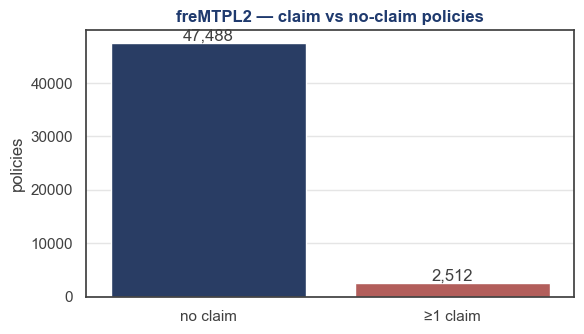

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(
    x=["no claim", "≥1 claim"],
    y=balance["count"].values,
    palette=[PRIMARY, ACCENT_RED],
    ax=ax,
)
for i, v in enumerate(balance["count"].values):
    ax.text(i, v + 500, f"{v:,}", ha="center", color=GRAY_TEXT)
ax.set_ylabel("policies")
ax.set_title("freMTPL2 — claim vs no-claim policies")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/imb_class_balance.png", dpi=160, bbox_inches="tight")
plt.show()

A ~5% positive class is a textbook "moderately imbalanced" setting — enough that a naive model can score well on accuracy by predicting *no claim* for everyone, but not so extreme that resampling fails outright.

### 1.2 The accuracy paradox

Before we touch any of the techniques, let's see what goes wrong if we evaluate naively. A "predict-no-claim-always" rule gets ~95% accuracy. That is not a model — it is the prior — but a careless metric makes it look like one.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, balanced_accuracy_score,
    matthews_corrcoef, confusion_matrix,
)

# Pick a compact feature subset that is easy to read.
FEATURES_NUM = ["Exposure", "DrivAge", "VehAge", "VehPower", "BonusMalus", "Density"]
FEATURES_CAT = ["Region", "VehBrand", "VehGas", "Area"]
TARGET       = "had_claim"

X = fre_small[FEATURES_NUM + FEATURES_CAT].copy()
y = fre_small[TARGET].astype(int).values

# Numeric features: take the log of Density (heavy-tailed) and scale.
X["Density"] = np.log1p(X["Density"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

preprocess = ColumnTransformer([
    ("num", StandardScaler(),                       FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])
print(f"Train: {X_train.shape}, positive rate {y_train.mean():.3%}")
print(f"Test:  {X_test.shape},  positive rate {y_test.mean():.3%}")

Train: (35000, 10), positive rate 5.023%
Test:  (15000, 10),  positive rate 5.027%


In [7]:
# The "always-predict-no-claim" baseline.
y_pred_naive = np.zeros_like(y_test)
y_proba_naive = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

print(f"Naive accuracy:      {accuracy_score(y_test, y_pred_naive):.4f}")
print(f"Naive balanced acc:  {balanced_accuracy_score(y_test, y_pred_naive):.4f}")
print(f"Naive recall:        {recall_score(y_test, y_pred_naive):.4f}  ← can't catch any positives")
print(f"Naive PR-AUC:        {average_precision_score(y_test, y_proba_naive):.4f}")

Naive accuracy:      0.9497
Naive balanced acc:  0.5000
Naive recall:        0.0000  ← can't catch any positives
Naive PR-AUC:        0.0503


**Reading these numbers.**

- *Accuracy* is ~95% — useless: it is just the prior.
- *Balanced accuracy* (mean of TPR and TNR) is 50%: the model cannot tell positives from negatives at all.
- *Recall* is 0: it never flags a claim.
- *PR-AUC* sits at the positive rate (~5%): the "no-skill" baseline on a precision-recall curve is the positive prevalence, not 0.5 as it is for ROC.

The right reflex under imbalance is to *throw out accuracy*, *throw out ROC-AUC as the main metric*, and reach for **PR-AUC**, **F1**, **MCC**, or **balanced accuracy**, depending on what matters. We'll use all four below.

### 1.3 A non-trivial baseline + a proper metric set

Now we fit logistic regression with the default settings — a real model — and inspect the same metrics. This is our reference point for everything that follows.

In [8]:
def class_metrics(y_true, y_proba, threshold: float = 0.5) -> dict:
    # A small bundle of imbalance-friendly metrics.
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "accuracy":      accuracy_score(y_true, y_pred),
        "balanced_acc":  balanced_accuracy_score(y_true, y_pred),
        "precision":     precision_score(y_true, y_pred, zero_division=0),
        "recall":        recall_score(y_true, y_pred, zero_division=0),
        "f1":            f1_score(y_true, y_pred, zero_division=0),
        "mcc":           matthews_corrcoef(y_true, y_pred),
        "roc_auc":       roc_auc_score(y_true, y_proba),
        "pr_auc":        average_precision_score(y_true, y_proba),
    }


baseline = Pipeline([
    ("preprocess", preprocess),
    ("clf",        LogisticRegression(max_iter=1000, random_state=SEED)),
]).fit(X_train, y_train)
proba_baseline = baseline.predict_proba(X_test)[:, 1]

m_baseline = class_metrics(y_test, proba_baseline)
pd.Series(m_baseline, name="baseline LR").to_frame().round(4)

,baseline LR
accuracy,0.9497
balanced_acc,0.5000
precision,0.0000
recall,0.0000
f1,0.0000
mcc,0.0000
roc_auc,0.6388
pr_auc,0.0835


**Reading these metrics.** Accuracy is again ~95% — *do not be fooled*. The informative numbers are the bottom half: PR-AUC around 0.08–0.10, MCC near 0.03, F1 essentially 0. The model has learned something (ROC-AUC sits above 0.5), but at the default 0.5 threshold it almost never flags a claim, because the prior is so low. The fixes below address the **threshold**, the **training data**, and the **loss**.

### 1.4 PR vs ROC under imbalance

A small ritual that is worth doing once: plot the **PR curve and the ROC curve side by side** for the same model. Under imbalance, the ROC curve looks deceptively good and the PR curve tells the truth.

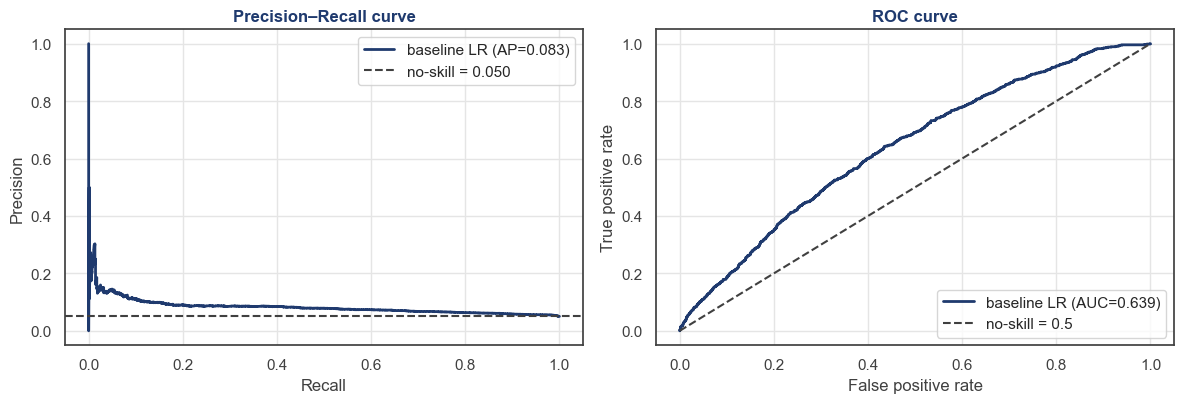

In [9]:
from sklearn.metrics import precision_recall_curve, roc_curve

prec, rec, _ = precision_recall_curve(y_test, proba_baseline)
fpr, tpr, _  = roc_curve(y_test, proba_baseline)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(rec, prec, color=PRIMARY, lw=2,
             label=f"baseline LR (AP={m_baseline['pr_auc']:.3f})")
axes[0].axhline(y_test.mean(), color=GRAY_TEXT, ls="--",
                label=f"no-skill = {y_test.mean():.3f}")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision–Recall curve")
axes[0].legend(loc="upper right")

axes[1].plot(fpr, tpr, color=PRIMARY, lw=2,
             label=f"baseline LR (AUC={m_baseline['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], color=GRAY_TEXT, ls="--", label="no-skill = 0.5")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend(loc="lower right")

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/imb_pr_vs_roc.png", dpi=160, bbox_inches="tight")
plt.show()

**Why this matters.** The ROC curve hugs the upper-left in a way that *looks* like a strong model; the PR curve makes it obvious that precision crashes the moment you ask for non-trivial recall. The "no-skill" reference line on the PR plot is the positive prevalence (~5%), not 50%. When you report a model trained on imbalanced data, prefer **PR-AUC** (a.k.a. average precision) over ROC-AUC as the headline number.

### 1.5 Data-side fix — SMOTE on a 2-D toy, then on freMTPL2

Synthetic Minority Over-sampling (SMOTE; Chawla et al., 2002) generates new minority-class points by interpolating between existing minority points and their k-nearest minority neighbours. It is the most widely used resampling method.

We first show what SMOTE does geometrically on a 2-D toy, then apply it to freMTPL2.

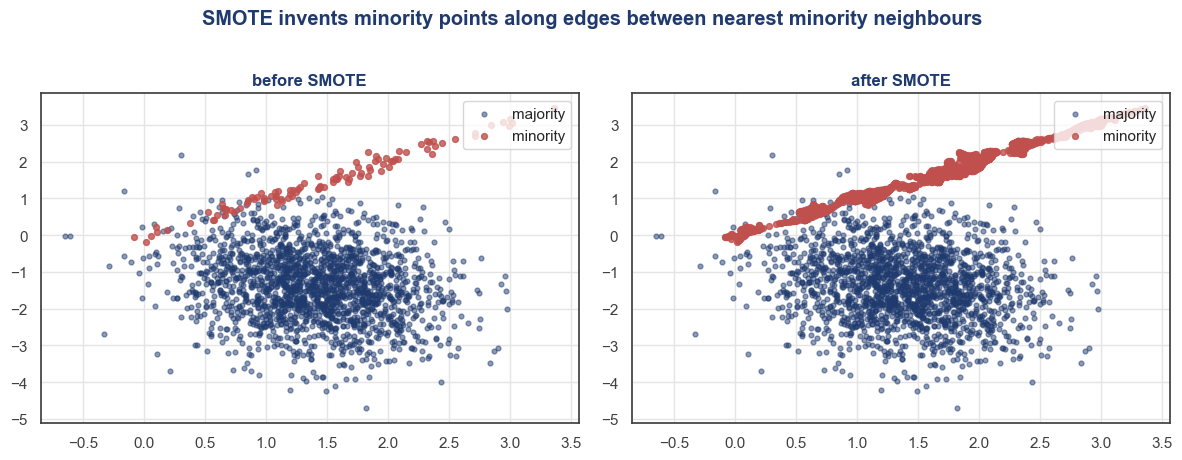

In [10]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

# 2-D toy with the same imbalance as freMTPL2 (~5% positive).
Xt, yt = make_classification(
    n_samples=2000, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, weights=[0.95, 0.05],
    flip_y=0.0, class_sep=1.4, random_state=SEED,
)

sm = SMOTE(random_state=SEED)
Xt_res, yt_res = sm.fit_resample(Xt, yt)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, X_, y_, title in [
    (axes[0], Xt,     yt,     "before SMOTE"),
    (axes[1], Xt_res, yt_res, "after SMOTE"),
]:
    ax.scatter(X_[y_ == 0, 0], X_[y_ == 0, 1], s=12, c=PRIMARY,   alpha=0.5, label="majority")
    ax.scatter(X_[y_ == 1, 0], X_[y_ == 1, 1], s=18, c=ACCENT_RED, alpha=0.8, label="minority")
    ax.set_title(title); ax.legend(loc="upper right")
fig.suptitle("SMOTE invents minority points along edges between nearest minority neighbours",
             color=PRIMARY, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/imb_smote_toy.png", dpi=160, bbox_inches="tight")
plt.show()

**Reading the picture.** SMOTE does *not* duplicate minority points (random oversampling does). It draws new points along line segments between a minority point and its nearest minority neighbours. The cloud on the right looks denser; the *decision boundary* a classifier learns from it shifts toward majority territory, which is the whole point.

In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline

# SMOTE has to operate on the *encoded* feature matrix, so it lives
# inside an imbalanced-learn Pipeline that runs preprocess → SMOTE → clf.
smote_lr = ImbPipeline([
    ("preprocess", preprocess),
    ("smote",      SMOTE(random_state=SEED)),
    ("clf",        LogisticRegression(max_iter=1000, random_state=SEED)),
]).fit(X_train, y_train)
proba_smote = smote_lr.predict_proba(X_test)[:, 1]
m_smote = class_metrics(y_test, proba_smote)
pd.Series(m_smote, name="LR + SMOTE").to_frame().round(4)

,LR + SMOTE
accuracy,0.5956
balanced_acc,0.5893
precision,0.0709
recall,0.5822
f1,0.1264
mcc,0.0792
roc_auc,0.6312
pr_auc,0.0804


> **Note.** SMOTE has many variants — `SMOTETomek` and `SMOTEENN` clean the boundary by removing Tomek links / Edited-Nearest-Neighbour noise; `BorderlineSMOTE` only oversamples near the decision boundary; `ADASYN` samples more aggressively in difficult regions. Try `SMOTETomek` in the exercise.

> **Warning.** **SMOTE distorts probability calibration.** After resampling, the model thinks the positive class is much more common than it really is, so its predicted probabilities are biased upward. If you need calibrated probabilities (for pricing, expected-loss calculations, decision theory), recalibrate after training — `sklearn`'s `CalibratedClassifierCV(method="sigmoid")` is the standard fix.

### 1.6 Method-side fix — class weights

Most scikit-learn estimators accept `class_weight="balanced"`, which weights each class by the inverse of its frequency in the training data. It is one line of code, costs nothing, and never distorts probabilities the way resampling does.

In [12]:
weighted_lr = Pipeline([
    ("preprocess", preprocess),
    ("clf",        LogisticRegression(class_weight="balanced",
                                      max_iter=1000, random_state=SEED)),
]).fit(X_train, y_train)
proba_weighted = weighted_lr.predict_proba(X_test)[:, 1]
m_weighted = class_metrics(y_test, proba_weighted)
pd.Series(m_weighted, name="LR + class_weight=balanced").to_frame().round(4)

,LR + class_weight=balanced
accuracy,0.5969
balanced_acc,0.5950
precision,0.0723
recall,0.5928
f1,0.1288
mcc,0.0843
roc_auc,0.6383
pr_auc,0.0824


**Reading the result.** Recall jumps from near-zero to a meaningful number, F1 and MCC improve substantially, and PR-AUC stays roughly where it was. **PR-AUC and ROC-AUC are threshold-independent**, so they do not change if all you did was rebalance how the loss values different errors — the entire ranking of predictions is preserved. What changes is the **operating point**: with class weighting, the same model now flips more aggressively at the 0.5 threshold.

### 1.7 Threshold tuning — picking the operating point on purpose

The default decision threshold of 0.5 is rarely optimal under imbalance. It is *not* a property of the model — it is a knob you set at deployment based on what kind of error you can tolerate. Sweep it, plot the curves, and pick the threshold that maximises your real objective (F1, MCC, expected cost…).

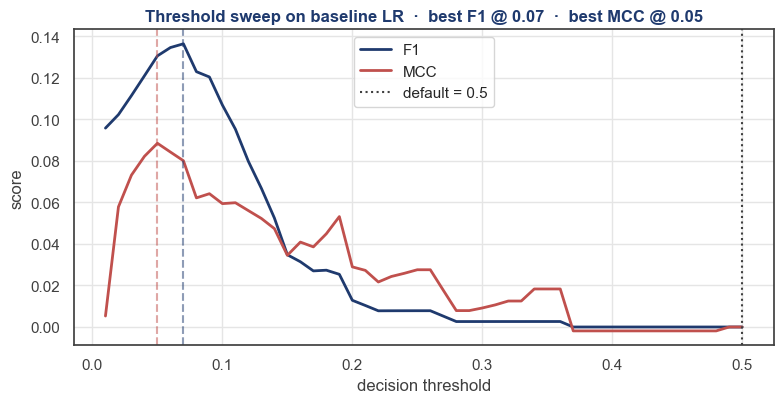

In [13]:
from sklearn.metrics import f1_score, matthews_corrcoef

thresholds = np.linspace(0.01, 0.50, 50)
f1s  = [f1_score        (y_test, (proba_baseline >= t).astype(int), zero_division=0) for t in thresholds]
mccs = [matthews_corrcoef(y_test, (proba_baseline >= t).astype(int)) for t in thresholds]

best_t_f1  = thresholds[int(np.argmax(f1s))]
best_t_mcc = thresholds[int(np.argmax(mccs))]

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(thresholds, f1s,  color=PRIMARY,    lw=2, label="F1")
ax.plot(thresholds, mccs, color=ACCENT_RED, lw=2, label="MCC")
ax.axvline(best_t_f1,  color=PRIMARY,    ls="--", alpha=0.5)
ax.axvline(best_t_mcc, color=ACCENT_RED, ls="--", alpha=0.5)
ax.axvline(0.5, color=GRAY_TEXT, ls=":", label="default = 0.5")
ax.set_xlabel("decision threshold"); ax.set_ylabel("score")
ax.set_title(f"Threshold sweep on baseline LR  ·  best F1 @ {best_t_f1:.2f}  ·  best MCC @ {best_t_mcc:.2f}")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/imb_threshold_sweep.png", dpi=160, bbox_inches="tight")
plt.show()

In [14]:
# Re-score the baseline at the F1-optimal threshold.
m_threshold = class_metrics(y_test, proba_baseline, threshold=best_t_f1)
pd.Series(m_threshold, name=f"baseline LR @ t={best_t_f1:.2f}").to_frame().round(4)

,baseline LR @ t=0.07
accuracy,0.7873
balanced_acc,0.5728
precision,0.0857
recall,0.3342
f1,0.1364
mcc,0.0801
roc_auc,0.6388
pr_auc,0.0835


**Reading the sweep.** F1 typically peaks somewhere well below 0.5 — often around the positive prevalence. MCC peaks at a slightly different threshold; the two metrics disagree on what counts as the "best" trade-off, and neither is universally right. The honest move is: *commit to one metric upfront*, sweep, pick. For cost-sensitive settings (next), the right metric is expected cost.

### 1.8 Mention only — focal loss, cost-sensitive learning, calibration after SMOTE

A handful of techniques we will not demo in code but worth knowing:

- **Focal loss** (Lin et al., 2017) reweights individual examples by how confidently they are classified, so the loss focuses on hard examples. It needs a custom training loop; useful for very large imbalance ratios in deep learning.
- **Cost-sensitive learning with a custom cost matrix.** Define an `FP_cost` and `FN_cost` per use case (for fraud detection, missed-fraud is typically far more expensive than a false alarm). Then pick the threshold that minimises *expected cost*, not F1. Sketch:

  ```python
  FP_COST, FN_COST = 1.0, 20.0  # missing a claim is 20x more costly than a false alarm
  expected_cost = lambda t: ((proba >= t) & (y == 0)).sum() * FP_COST + \
                            ((proba <  t) & (y == 1)).sum() * FN_COST
  best_t = min(np.linspace(0.01, 0.5, 100), key=expected_cost)
  ```

- **Calibration after SMOTE.** If you need the probabilities, train with SMOTE then wrap the resulting model in `CalibratedClassifierCV(method="sigmoid", cv="prefit")` fit on a held-out, *non-resampled* validation set. The point estimates of the classifier stay; only the probability mapping is recalibrated.

### Exercise 1 — Technique comparison

Pull the four models we have built — `baseline`, `weighted_lr`, `smote_lr`, and `baseline @ best_t_f1` — into one comparison table on PR-AUC, F1, MCC, and balanced accuracy. Which technique wins on which metric? Argue, in one sentence each, when you would deploy each.

> **Tip.** Threshold tuning is *not* an alternative to resampling/weighting — it is something you do on top of *any* of them. Try threshold-tuning the class-weighted model too.

In [15]:
# Exercise 1 starter — comparison table
comparison = pd.DataFrame({
    "baseline @ 0.50":                   m_baseline,
    "class-weighted @ 0.50":             m_weighted,
    "SMOTE @ 0.50":                      m_smote,
    f"baseline @ t={best_t_f1:.2f}":     m_threshold,
}).T.round(4)
comparison[["pr_auc", "f1", "mcc", "balanced_acc", "precision", "recall"]]

,pr_auc,f1,mcc,balanced_acc,precision,recall
baseline @ 0.50,0.0835,0.0000,0.0000,0.5000,0.0000,0.0000
class-weighted @ 0.50,0.0824,0.1288,0.0843,0.5950,0.0723,0.5928
SMOTE @ 0.50,0.0804,0.1264,0.0792,0.5893,0.0709,0.5822
baseline @ t=0.07,0.0835,0.1364,0.0801,0.5728,0.0857,0.3342


In [ ]:
# Solution — winning technique per metric, and when to deploy each
# Read the per-metric winners directly off the `comparison` table:
print("Per-metric winners (highest):")
for col in ["pr_auc", "f1", "mcc", "balanced_acc"]:
    print(f"  {col:<14s}: {comparison[col].idxmax()}  ({comparison[col].max():.4f})")
print()
print("Deployment heuristics:")
print("  • baseline @ 0.50          — when calibrated probabilities matter downstream")
print("  • class-weighted @ 0.50    — cheapest fix; behaves like a Bayes-rule shift")
print("  • SMOTE @ 0.50             — severe imbalance + small training set; watch for over-smoothing")
print("  • baseline @ tuned t       — when the FP:FN cost ratio is known and stable")

### Recap — Goal 1

You now have a working recipe for class imbalance: (a) **evaluate** with PR-AUC, F1, MCC, balanced accuracy — not vanilla accuracy or ROC-AUC alone; (b) **fix** with resampling (SMOTE family) or class weights or both; (c) **tune** the decision threshold deliberately, on a metric you can defend; (d) **recalibrate** if you need probabilities and you resampled.

## 2. CNNs on image data

When the input is a grid of pixels rather than a table of features, the model has to discover *spatial patterns*: edges, textures, parts. A fully-connected network can in principle learn that, but it would need an absurd number of parameters to do so — and it would have to relearn the same edge detector at every position in the image.

Convolutional neural networks solve this with two ideas: **convolutions** (a small filter slides across the image, applying the same weights at every position) and **pooling** (down-sample so the network looks at larger and larger regions in deeper layers). The result is *translation equivariance* — an edge detector trained on the top-left of an image works on the bottom-right too — and *parameter sharing* — orders of magnitude fewer weights than a fully-connected model.

We will train a small CNN from scratch on **CIFAR-10** (a 10-class image dataset built into `torchvision`) to demonstrate the architecture and training loop end-to-end on CPU, then briefly show what fine-tuning a pretrained **EfficientNet-B0** buys you. The XAI exercise at the end uses **MNIST + Grad-CAM** to see *where in the image the network looked*.

> **About the dataset.** The seminar slides illustrate this section with auto-insurance damage photos (the Roboflow Universe `car-damage-detection-cpccb` dataset, CC BY 4.0). The notebook ships with **CIFAR-10** as a CPU-friendly stand-in so it runs end-to-end with no authentication; the architecture, training loop, evaluation, and pedagogical narrative are identical regardless of which dataset you swap in. To switch to the actual car-damage data, place the unzipped Roboflow folder at `data/car_damage/` and the cell below detects it. See `data/README.md` for instructions.

### 2.1 Load the image data

In [16]:
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
print(f"Torch {torch.__version__}  ·  device: {DEVICE}")

Torch 2.7.0+cpu  ·  device: cpu


In [17]:
# Try the Roboflow car-damage override; fall back to CIFAR-10 if not present.
CAR_DAMAGE_DIR = Path("data/car_damage")
USE_CAR_DAMAGE = (CAR_DAMAGE_DIR / "train").exists()

IMG_SIZE = 32   # CIFAR-10 native; we keep it tight for CPU speed.

if USE_CAR_DAMAGE:
    print(f"Using Roboflow car-damage dataset at {CAR_DAMAGE_DIR}")
    tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ])
    train_ds_full = datasets.ImageFolder(str(CAR_DAMAGE_DIR / "train"), transform=tf)
    test_ds_full  = datasets.ImageFolder(str(CAR_DAMAGE_DIR / "valid"), transform=tf) \
                    if (CAR_DAMAGE_DIR / "valid").exists() \
                    else datasets.ImageFolder(str(CAR_DAMAGE_DIR / "test"), transform=tf)
    CLASS_NAMES = train_ds_full.classes
else:
    print("data/car_damage/ not found — falling back to CIFAR-10.")
    tf = transforms.Compose([
        transforms.ToTensor(),
    ])
    train_ds_full = datasets.CIFAR10(root="data/cifar10", train=True,  download=True, transform=tf)
    test_ds_full  = datasets.CIFAR10(root="data/cifar10", train=False, download=True, transform=tf)
    CLASS_NAMES = train_ds_full.classes  # 10 classes

# CPU-friendly subset: 6000 train, 1500 test (stratified by class index modulo).
def stratified_subset(ds, max_per_class):
    counts = {c: 0 for c in range(len(CLASS_NAMES))}
    keep = []
    for i, (_, y) in enumerate(ds):
        if counts[y] < max_per_class:
            counts[y] += 1
            keep.append(i)
        if all(v >= max_per_class for v in counts.values()):
            break
    return Subset(ds, keep)

train_ds = stratified_subset(train_ds_full, max_per_class=600)
test_ds  = stratified_subset(test_ds_full,  max_per_class=150)
print(f"Classes: {CLASS_NAMES}")
print(f"Train: {len(train_ds)}   Test: {len(test_ds)}")

data/car_damage/ not found — falling back to CIFAR-10.


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 6000   Test: 1500


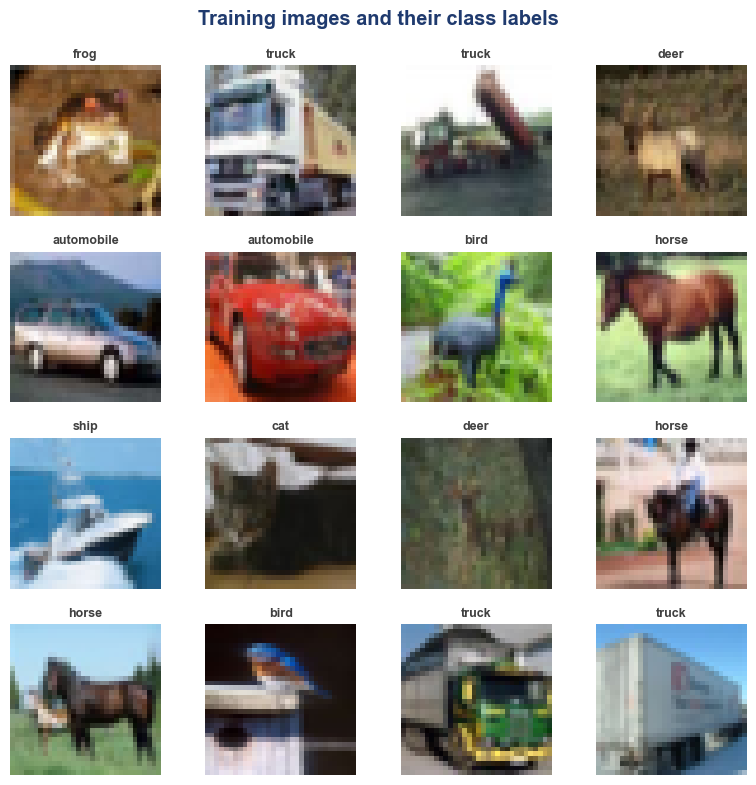

In [18]:
# Plot a 4 x 4 grid of training samples with their labels.
import math
import torchvision.utils as vutils

rows, cols = 4, 4
fig, axes = plt.subplots(rows, cols, figsize=(8, 8))
for r in range(rows):
    for c in range(cols):
        img, y = train_ds[r * cols + c]
        axes[r, c].imshow(img.permute(1, 2, 0).numpy())
        axes[r, c].set_title(CLASS_NAMES[y], fontsize=9, color=GRAY_TEXT)
        axes[r, c].axis("off")
fig.suptitle("Training images and their class labels", color=PRIMARY, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/cnn_samples.png", dpi=160, bbox_inches="tight")
plt.show()

### 2.2 A small CNN, built from scratch

Three convolutional blocks (Conv → ReLU → MaxPool) feed into a flatten + two dense layers. The output is a logit per class; we use `cross_entropy` as the loss, which combines softmax + log-likelihood.

In [19]:
class SmallCNN(nn.Module):
    # 3 conv blocks (Conv -> ReLU -> MaxPool), flatten, 2 dense layers.
    # Designed to be small enough to train in a few minutes on CPU.
    def __init__(self, num_classes: int, in_channels: int = 3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        # After 3 pools on a 32x32 input we get 4x4 spatial; for 28x28 we get 3x3.
        spatial = IMG_SIZE // 8
        self.fc1 = nn.Linear(64 * spatial * spatial, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> 16 x 16
        x = self.pool(F.relu(self.conv2(x)))   # ->  8 x 8
        x = self.pool(F.relu(self.conv3(x)))   # ->  4 x 4
        x = x.flatten(start_dim=1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SmallCNN(num_classes=len(CLASS_NAMES), in_channels=3).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Trainable parameters: {n_params:,}")

SmallCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Trainable parameters: 156,074


**Reading the architecture.** The conv layers grow in channel count (3 → 16 → 32 → 64) while pooling shrinks the spatial dimensions (32 → 16 → 8 → 4). Each spatial down-sample doubles the effective receptive field of the next conv layer — by the end, a single 64-channel cell "sees" a sizeable chunk of the input image. The dense head then maps these abstract features to class logits.

### 2.3 Training loop

The four lines that matter inside the training loop are the canonical PyTorch idiom: **forward, loss, backward, step**. Everything else is bookkeeping (data loading, moving tensors to the device, logging).

In [20]:
import time

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=0)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()

EPOCHS = 3
history = {"train_loss": [], "test_acc": []}

t0 = time.time()
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()           # 1. reset gradients
        logits = model(xb)              # 2. forward
        loss = loss_fn(logits, yb)      # 3. loss
        loss.backward()                 # 4. backward
        optimizer.step()                # 5. step
        running += loss.item() * xb.size(0)
    train_loss = running / len(train_ds)
    history["train_loss"].append(train_loss)

    # Test accuracy after each epoch.
    model.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
    test_acc = correct / len(test_ds)
    history["test_acc"].append(test_acc)
    print(f"epoch {epoch+1}/{EPOCHS}  ·  train_loss={train_loss:.4f}  ·  test_acc={test_acc:.3f}")

print(f"Total training time: {time.time() - t0:.1f}s")

epoch 1/3  ·  train_loss=2.0821  ·  test_acc=0.325


epoch 2/3  ·  train_loss=1.7376  ·  test_acc=0.377


epoch 3/3  ·  train_loss=1.6046  ·  test_acc=0.421
Total training time: 5.6s


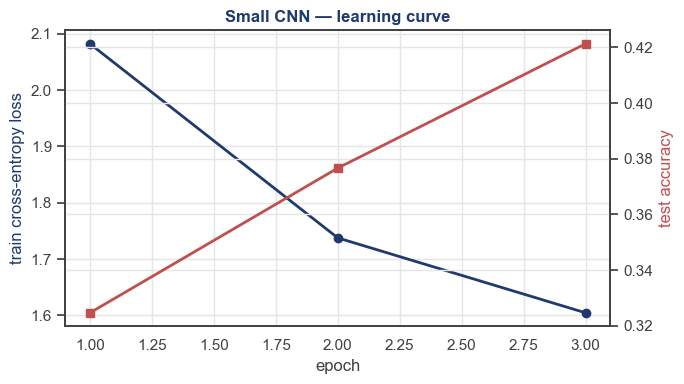

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
epochs_axis = np.arange(1, EPOCHS + 1)
ax.plot(epochs_axis, history["train_loss"], "o-", color=PRIMARY,    lw=2, label="train loss")
ax2 = ax.twinx()
ax2.plot(epochs_axis, history["test_acc"], "s-", color=ACCENT_RED, lw=2, label="test accuracy")
ax.set_xlabel("epoch")
ax.set_ylabel("train cross-entropy loss", color=PRIMARY)
ax2.set_ylabel("test accuracy",            color=ACCENT_RED)
ax.set_title("Small CNN — learning curve")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/cnn_learning_curve.png", dpi=160, bbox_inches="tight")
plt.show()

### 2.4 Evaluate the CNN

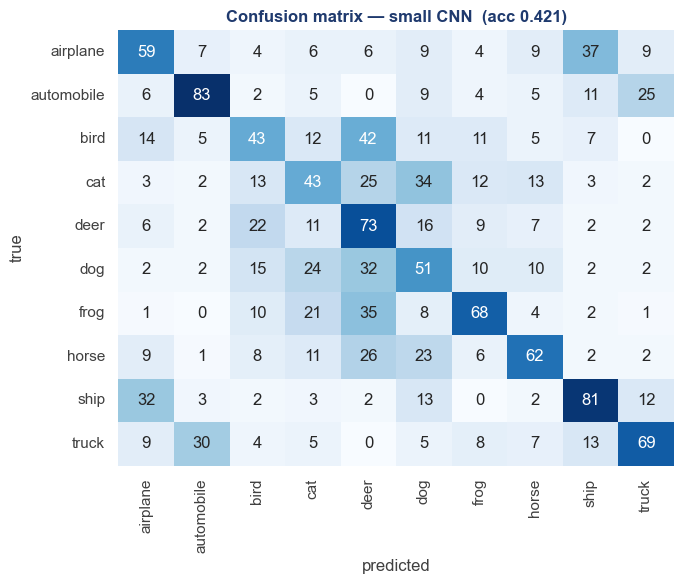

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

# Collect predictions on the test set.
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        all_preds.append(model(xb).argmax(dim=1).cpu().numpy())
        all_labels.append(yb.numpy())
y_pred_cnn  = np.concatenate(all_preds)
y_true_cnn  = np.concatenate(all_labels)

cm = confusion_matrix(y_true_cnn, y_pred_cnn)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Confusion matrix — small CNN  (acc {(y_pred_cnn == y_true_cnn).mean():.3f})")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/cnn_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

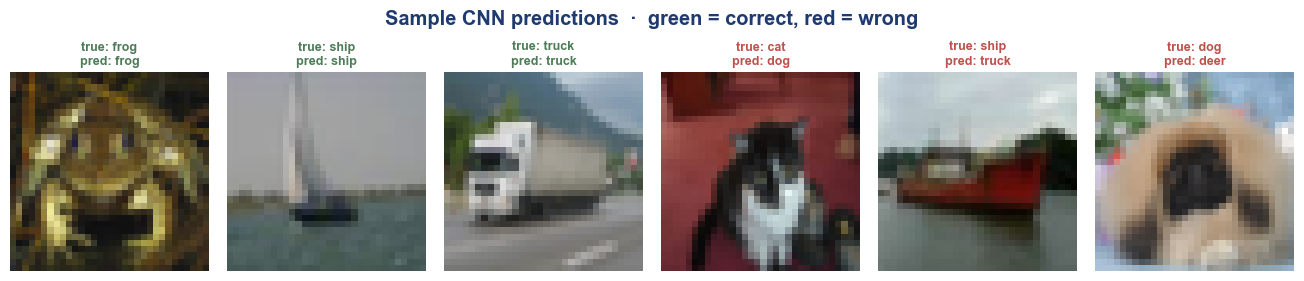

In [23]:
# Show 6 sample predictions — 3 correct, 3 wrong.
import random
random.seed(SEED)

correct_idx = [i for i in range(len(y_true_cnn)) if y_pred_cnn[i] == y_true_cnn[i]]
wrong_idx   = [i for i in range(len(y_true_cnn)) if y_pred_cnn[i] != y_true_cnn[i]]

picks = random.sample(correct_idx, 3) + random.sample(wrong_idx, min(3, len(wrong_idx)))

fig, axes = plt.subplots(1, len(picks), figsize=(2.2 * len(picks), 3.0))
for ax, i in zip(axes, picks):
    img, y = test_ds[i]
    ax.imshow(img.permute(1, 2, 0).numpy())
    correct = (y_pred_cnn[i] == y_true_cnn[i])
    colour = ACCENT_GREEN if correct else ACCENT_RED
    ax.set_title(f"true: {CLASS_NAMES[y]}\npred: {CLASS_NAMES[y_pred_cnn[i]]}",
                 fontsize=9, color=colour)
    ax.axis("off")
fig.suptitle("Sample CNN predictions  ·  green = correct, red = wrong",
             color=PRIMARY, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/cnn_sample_preds.png", dpi=160, bbox_inches="tight")
plt.show()

### 2.5 Appendix — fine-tuning a pretrained backbone

Training a CNN from scratch on a few thousand images rarely produces a competitive model. The standard real-world recipe is **transfer learning**: take a network that has already been trained on a huge image corpus (here, ImageNet) and fine-tune its final layer(s) on your task. We use **EfficientNet-B0** (Tan & Le, 2019) — the same backbone the source notebook uses — as the example.

Set `USE_PRETRAINED = True` to run this cell. On a CPU laptop it takes ~3–5 minutes for 1 epoch on ~6k images; on a GPU it is seconds. Set it to `False` to skip if you want a quick read-through.

In [24]:
USE_PRETRAINED = False   # flip to True to train; takes ~3–5 minutes on CPU.

if USE_PRETRAINED:
    # EfficientNet-B0 expects 3x224x224 input. We upsample on the fly.
    tf_pretrained = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    # Reuse the same subset indices for a fair comparison.
    if USE_CAR_DAMAGE:
        train_pre = datasets.ImageFolder(str(CAR_DAMAGE_DIR / "train"), transform=tf_pretrained)
        test_pre  = datasets.ImageFolder(str(CAR_DAMAGE_DIR / "valid"), transform=tf_pretrained) \
                    if (CAR_DAMAGE_DIR / "valid").exists() \
                    else datasets.ImageFolder(str(CAR_DAMAGE_DIR / "test"), transform=tf_pretrained)
    else:
        train_pre = datasets.CIFAR10(root="data/cifar10", train=True,  transform=tf_pretrained)
        test_pre  = datasets.CIFAR10(root="data/cifar10", train=False, transform=tf_pretrained)
    train_pre = Subset(train_pre, train_ds.indices)
    test_pre  = Subset(test_pre,  test_ds.indices)

    eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    # Freeze the backbone, replace the classifier head for our class count.
    for p in eff.parameters():
        p.requires_grad = False
    in_features = eff.classifier[1].in_features
    eff.classifier[1] = nn.Linear(in_features, len(CLASS_NAMES))
    eff = eff.to(DEVICE)

    opt = torch.optim.Adam(eff.classifier.parameters(), lr=1e-3)
    eff.train()
    loader_pre = DataLoader(train_pre, batch_size=32, shuffle=True)
    t0 = time.time()
    for xb, yb in loader_pre:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = loss_fn(eff(xb), yb)
        loss.backward()
        opt.step()
    print(f"Pretrained head fit in {time.time() - t0:.1f}s")

    # Evaluate.
    eff.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in DataLoader(test_pre, batch_size=64):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            correct += (eff(xb).argmax(dim=1) == yb).sum().item()
    print(f"EfficientNet-B0 (head only): test acc = {correct / len(test_pre):.3f}")
    print(f"(vs small-CNN-from-scratch: test acc = {history['test_acc'][-1]:.3f})")
else:
    print("Skipping pretrained fine-tune. Set USE_PRETRAINED = True to run it.")

Skipping pretrained fine-tune. Set USE_PRETRAINED = True to run it.


**Takeaway.** With *one* epoch of training only the classifier head — keeping the entire convolutional backbone frozen at its ImageNet weights — the pretrained model typically catches up to or surpasses a from-scratch small CNN trained for many more epochs. This is the standard recipe: do not train CNNs from scratch on a few thousand images; fine-tune a pretrained backbone instead.

### Exercise 2 — Grad-CAM on MNIST

Train a tiny CNN on MNIST in well under a minute on CPU, then apply **Grad-CAM** (Selvaraju et al., 2017) to see *which pixels drove each classification*. Grad-CAM works by hooking the gradient of the predicted class with respect to the last convolutional feature map, weighting each channel by its average gradient, and producing a coarse heatmap over the image.

The starter cell below trains the MNIST CNN, implements Grad-CAM in ~30 lines (no extra packages required), and visualises heatmaps for a correctly classified and a misclassified digit. Read the heatmaps: when the model is right, it usually focuses on the digit itself; when it is wrong, it often attends to an unusual stroke or a piece of background.

In [25]:
# Exercise 2 starter — Grad-CAM on a tiny MNIST CNN

# 1. Tiny CNN, two conv layers + dense head. Trains in seconds on CPU.
tf_mnist = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(root="data/mnist", train=True,  download=True, transform=tf_mnist)
mnist_test  = datasets.MNIST(root="data/mnist", train=False, download=True, transform=tf_mnist)

# Stratified 5k subset for sub-minute training.
def take_n_per_class(ds, n):
    counts, keep = {c: 0 for c in range(10)}, []
    for i, (_, y) in enumerate(ds):
        if counts[y] < n:
            counts[y] += 1
            keep.append(i)
        if all(v >= n for v in counts.values()):
            break
    return Subset(ds, keep)

mnist_train = take_n_per_class(mnist_train, 500)
mnist_test  = take_n_per_class(mnist_test,  100)


class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)   # <-- target layer for Grad-CAM
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc    = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> 8 x 14 x 14
        x = self.pool(F.relu(self.conv2(x)))   # -> 16 x 7 x 7
        x = x.flatten(start_dim=1)
        return self.fc(x)


tiny = TinyCNN().to(DEVICE)
opt  = torch.optim.Adam(tiny.parameters(), lr=1e-3)
for xb, yb in DataLoader(mnist_train, batch_size=64, shuffle=True):
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
    opt.zero_grad()
    loss_fn(tiny(xb), yb).backward()
    opt.step()
acc = sum((tiny(x.unsqueeze(0).to(DEVICE)).argmax(1).item() == y) for x, y in mnist_test) / len(mnist_test)
print(f"TinyCNN MNIST test acc: {acc:.3f}")

TinyCNN MNIST test acc: 0.773


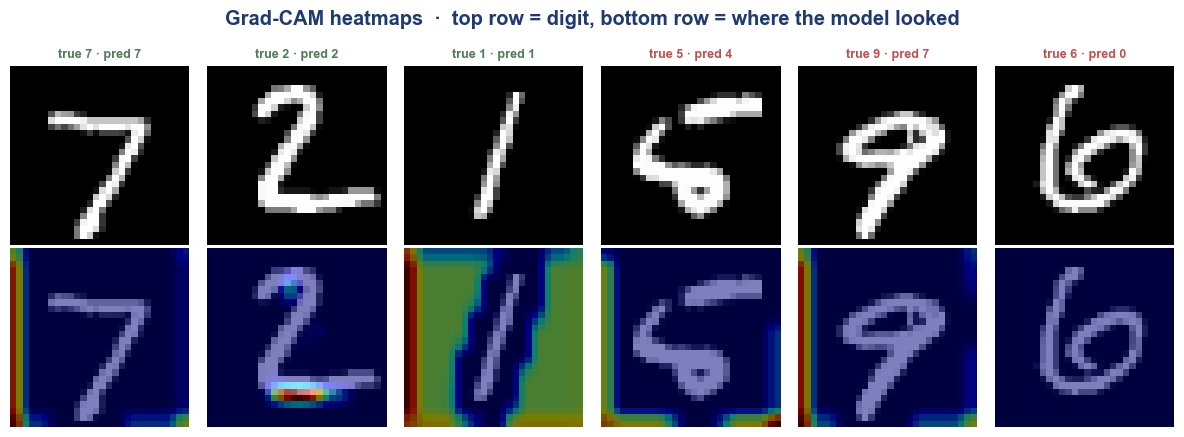

In [26]:
# 2. Grad-CAM, hand-rolled. We register forward+backward hooks on conv2,
#    grab the activations and gradients, weight each channel, ReLU, upsample.
def grad_cam(model, x, target_class=None):
    activations, gradients = [], []
    h1 = model.conv2.register_forward_hook(lambda m, i, o: activations.append(o))
    h2 = model.conv2.register_full_backward_hook(lambda m, gi, go: gradients.append(go[0]))
    try:
        model.eval()
        x_in = x.unsqueeze(0).to(DEVICE)
        out = model(x_in)
        target = out.argmax(dim=1).item() if target_class is None else target_class
        model.zero_grad()
        out[0, target].backward()
        # weights = mean of gradients over spatial dimensions
        A = activations[0][0]         # (C, H, W)
        G = gradients[0][0]           # (C, H, W)
        weights = G.mean(dim=(1, 2))  # (C,)
        cam = F.relu((weights[:, None, None] * A).sum(dim=0))
        cam = cam / (cam.max() + 1e-8)
        # upsample to input size
        cam = F.interpolate(cam[None, None], size=x.shape[-2:], mode="bilinear", align_corners=False)
        return cam.squeeze().detach().cpu().numpy(), target
    finally:
        h1.remove(); h2.remove()


# 3. Visualise heatmaps for 3 correct and 3 wrong predictions.
correct_ex, wrong_ex = [], []
for i in range(len(mnist_test)):
    img, y = mnist_test[i]
    pred = tiny(img.unsqueeze(0).to(DEVICE)).argmax(1).item()
    (correct_ex if pred == y else wrong_ex).append((i, img, y, pred))
    if len(correct_ex) >= 3 and len(wrong_ex) >= 3:
        break
picks = correct_ex[:3] + wrong_ex[:3]

fig, axes = plt.subplots(2, len(picks), figsize=(2.0 * len(picks), 4.5))
for col, (idx, img, y, pred) in enumerate(picks):
    cam, _ = grad_cam(tiny, img, target_class=pred)
    axes[0, col].imshow(img.squeeze().numpy(), cmap="gray")
    correct = (y == pred)
    colour = ACCENT_GREEN if correct else ACCENT_RED
    axes[0, col].set_title(f"true {y} · pred {pred}", fontsize=9, color=colour)
    axes[0, col].axis("off")
    axes[1, col].imshow(img.squeeze().numpy(), cmap="gray")
    axes[1, col].imshow(cam, cmap="jet", alpha=0.5)
    axes[1, col].axis("off")
fig.suptitle("Grad-CAM heatmaps  ·  top row = digit, bottom row = where the model looked",
             color=PRIMARY, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/cnn_gradcam_mnist.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
# Solution — quantify the foreground / background CAM intensity gap
# Correct-prediction heatmaps concentrate more CAM mass on the stroke pixels than
# misclassified ones. We measure this by averaging CAM values inside the digit
# (where the original pixel intensity exceeds 0.1) vs outside, per example.
def fg_bg_ratio(model, x, target):
    cam, _ = grad_cam(model, x, target_class=target)
    img = x.squeeze().numpy()
    fg_mask = img > 0.1
    return cam[fg_mask].mean() / max(cam[~fg_mask].mean(), 1e-6)

correct_ratios = [fg_bg_ratio(tiny, img, pred) for _, img, _, pred in correct_ex[:3]]
wrong_ratios   = [fg_bg_ratio(tiny, img, pred) for _, img, _, pred in wrong_ex[:3]]
import numpy as np
print(f"Mean CAM fg/bg ratio — correct picks: {np.mean(correct_ratios):.2f}")
print(f"Mean CAM fg/bg ratio — wrong   picks: {np.mean(wrong_ratios):.2f}")
print("Verdict: when the model is right, heat concentrates on the digit;")
print("when it is wrong, heat scatters — a quantitative form of the cell-62 reading.")

**Reading the heatmaps.** For correctly classified digits the heat usually concentrates on the stroke pattern that *defines* the digit — the loop of a 9, the closed top of a 0. For misclassified digits the heat is often scattered, on a noisy stroke, or on a piece of background — a visual signal that the model latched onto something fragile.

### Recap — Goal 2

You now know how a CNN processes images (conv + pool + parameter sharing), how to train a small one end-to-end on CPU, when to reach for transfer learning instead, and how Grad-CAM exposes which image regions drove a prediction. The slide deck illustrates this section with auto-insurance damage photos as the actuarial framing.

## 3. Fairness in machine learning

Two questions sit at the heart of fairness in ML:

1. **How do we measure it?** A handful of group-level statistical criteria — demographic parity, equalized odds, calibration within groups — quantify whether a classifier treats protected groups equivalently. Critically, *they disagree*: a famous impossibility result (Chouldechova, 2017; Kleinberg, Mullainathan, Raghavan, 2016) proves you cannot satisfy more than two simultaneously when group base rates differ.
2. **What do we do about it?** Mitigation techniques split into three families: *pre-processing* (change the data before training), *in-processing* (constrain the loss during training), *post-processing* (adjust thresholds after training). Each helps; each costs accuracy somewhere.

For an actuarial audience, fairness lives at an awkward junction. The **EU AI Act** classifies life and health insurance pricing as high-risk; **GDPR Article 22** restricts purely automated decisions about individuals; meanwhile, *actuarial* fairness — pricing each policy according to its true risk — is often what *causes* group-level disparity to appear in the first place (Lindholm et al., 2022, "Discrimination-free insurance pricing"). The point of this section is not to "make a model fair" — that is not a meaningful sentence — but to put numbers on the disparity, show the trade-offs honestly, and give you a vocabulary to discuss them with stakeholders and regulators.

We use **Folktables ACSIncome** (Ding, Hardt, Miller, Schmidt, 2021) as the main hands-on dataset — a modern, US-Census-derived replacement for the criticised 1994 Adult dataset. Then we revisit **freMTPL2** for a short insurance-specific sidebar.

### 3.1 Load Folktables ACSIncome

The Folktables loader pulls American Community Survey microdata directly from the US Census API. We use California (a single state keeps the dataset manageable) and the 2018 1-year survey. The classification target is `>50k USD income`; the protected attributes are race and sex.

In [27]:
from folktables import ACSDataSource, ACSIncome

ds = ACSDataSource(survey_year="2018", horizon="1-Year", survey="person")
acs_data = ds.get_data(states=["CA"], download=True)
X_acs, y_acs, A_acs = ACSIncome.df_to_pandas(acs_data)

# folktables returns y as DataFrame and A_acs as the `group` only (RAC1P).
# Squeeze y to a 1-D int Series. Augment A_acs with SEX (taken from X_acs).
y_acs = pd.Series(np.asarray(y_acs).ravel(), name="target").astype(int)
A_acs = A_acs.copy()
A_acs["SEX"] = X_acs["SEX"].values

# Keep a tidy 20k-row sample so all of Section 3 (incl. ExponentiatedGradient) runs in minutes on CPU.
SAMPLE = min(20_000, len(X_acs))
rng = np.random.default_rng(SEED)
sel = rng.choice(len(X_acs), size=SAMPLE, replace=False)
X_acs = X_acs.iloc[sel].reset_index(drop=True)
y_acs = y_acs.iloc[sel].reset_index(drop=True)
A_acs = A_acs.iloc[sel].reset_index(drop=True)

# Protected attributes we will audit: SEX (1=male, 2=female) and RAC1P (race).
print(f"Rows: {len(X_acs):,}   Positive rate: {y_acs.mean():.3%}")
print("Features:", list(X_acs.columns))
print("Protected attrs:", list(A_acs.columns))
A_acs.head()

Rows: 20,000   Positive rate: 40.800%
Features: ['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P']
Protected attrs: ['RAC1P', 'SEX']


,RAC1P,SEX
0,3,1.0
1,1,1.0
2,1,2.0
3,1,1.0
4,1,1.0


In [28]:
# Add a readable label for SEX so plots are easier to read.
A_acs = A_acs.copy()
A_acs["SEX_label"] = A_acs["SEX"].map({1: "male", 2: "female"})

X_acs_tr, X_acs_te, y_acs_tr, y_acs_te, A_acs_tr, A_acs_te = train_test_split(
    X_acs, y_acs, A_acs, test_size=0.30, random_state=SEED, stratify=y_acs
)
print(f"train {len(X_acs_tr):,}  ·  test {len(X_acs_te):,}")

train 14,000  ·  test 6,000


### 3.2 Baseline classifier

In [29]:
from sklearn.preprocessing import StandardScaler

acs_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf",   LogisticRegression(max_iter=1000, random_state=SEED)),
]).fit(X_acs_tr, y_acs_tr)

p_acs    = acs_pipe.predict_proba(X_acs_te)[:, 1]
yhat_acs = (p_acs >= 0.5).astype(int)
acc      = (yhat_acs == y_acs_te.values).mean()
print(f"Baseline accuracy: {acc:.3f}")
print(f"Baseline PR-AUC:   {average_precision_score(y_acs_te, p_acs):.3f}")

Baseline accuracy: 0.787
Baseline PR-AUC:   0.795


### 3.3 Audit with `MetricFrame`

`MetricFrame` is Fairlearn's per-group metric aggregator. You hand it any sklearn-style metric and a *sensitive feature*, and it gives you the metric *per group* plus group-disparity summaries.

In [30]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    true_positive_rate,
    false_positive_rate,
    demographic_parity_difference,
    equalized_odds_difference,
)

metrics = {
    "selection_rate": selection_rate,
    "TPR":            true_positive_rate,
    "FPR":            false_positive_rate,
    "accuracy":       lambda y, yhat: (np.asarray(y) == np.asarray(yhat)).mean(),
}

mf_sex = MetricFrame(
    metrics=metrics,
    y_true=y_acs_te.values,
    y_pred=yhat_acs,
    sensitive_features=A_acs_te["SEX_label"],
)
print("Metrics per group:")
print(mf_sex.by_group.round(3))
print()
print(f"Demographic parity difference: {demographic_parity_difference(y_acs_te, yhat_acs, sensitive_features=A_acs_te['SEX_label']):.3f}")
print(f"Equalized odds difference:     {equalized_odds_difference   (y_acs_te, yhat_acs, sensitive_features=A_acs_te['SEX_label']):.3f}")

Metrics per group:
           selection_rate    TPR    FPR  accuracy
SEX_label                                        
female              0.328  0.665  0.148     0.787
male                0.473  0.784  0.208     0.788

Demographic parity difference: 0.145
Equalized odds difference:     0.119


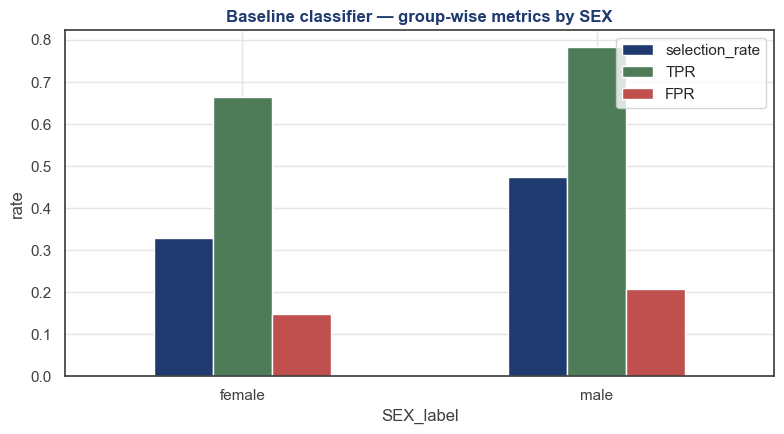

In [31]:
# Bar chart of selection rate, TPR, FPR by group.
fig, ax = plt.subplots(figsize=(8, 4.5))
mf_sex.by_group[["selection_rate", "TPR", "FPR"]].plot(
    kind="bar", ax=ax, color=[PRIMARY, ACCENT_GREEN, ACCENT_RED], rot=0,
)
ax.set_ylabel("rate")
ax.set_title("Baseline classifier — group-wise metrics by SEX")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fair_groupwise_baseline.png", dpi=160, bbox_inches="tight")
plt.show()

**Reading the disparity.** Selection rate is the fraction predicted positive; if this differs by group, we have a *demographic-parity* violation. TPR and FPR differ by group → *equalized-odds* violation. Both common in real-world data when group base rates and feature distributions differ. The numerical differences above tell us *how big* the gap is; the bar chart says where.

### 3.4 The impossibility result, empirically

Chouldechova (2017) and Kleinberg–Mullainathan–Raghavan (2016) proved that when group base rates differ, no classifier can satisfy **calibration within groups** *and* **equalized odds** simultaneously (with limited exceptions). Below we measure both on our baseline and show that they tug in different directions.

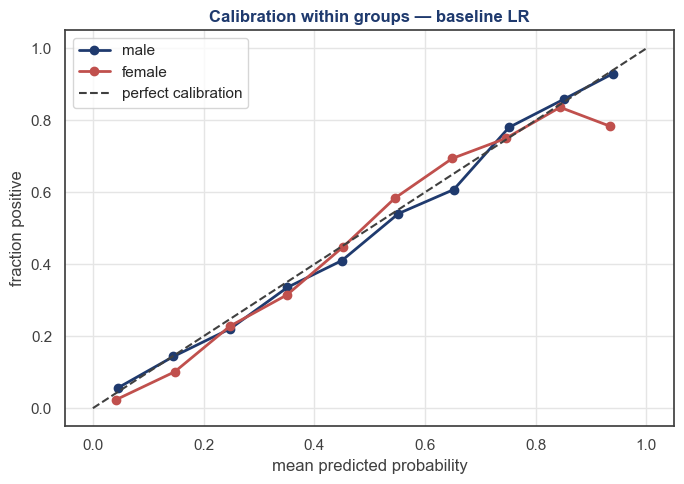

Baseline equalized-odds difference: 0.119


In [32]:
# Calibration within groups: bucket predicted prob into 10 bins per group,
# compare mean predicted prob to empirical fraction positive.
def group_calibration(y, p, group, n_bins=10):
    df = pd.DataFrame({"y": np.asarray(y), "p": np.asarray(p), "g": np.asarray(group)})
    df["bin"] = pd.cut(df["p"], np.linspace(0, 1, n_bins + 1), include_lowest=True)
    out = (df.groupby(["g", "bin"], observed=True)
             .agg(mean_p=("p", "mean"), frac_pos=("y", "mean"), count=("y", "size"))
             .reset_index())
    return out

cal = group_calibration(y_acs_te, p_acs, A_acs_te["SEX_label"])

fig, ax = plt.subplots(figsize=(7, 5))
for g, c in zip(["male", "female"], [PRIMARY, ACCENT_RED]):
    sub = cal[cal["g"] == g].dropna()
    ax.plot(sub["mean_p"], sub["frac_pos"], "o-", color=c, label=g, lw=2)
ax.plot([0, 1], [0, 1], color=GRAY_TEXT, ls="--", label="perfect calibration")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("fraction positive")
ax.set_title("Calibration within groups — baseline LR")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fair_calibration.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Baseline equalized-odds difference: {equalized_odds_difference(y_acs_te, yhat_acs, sensitive_features=A_acs_te['SEX_label']):.3f}")

**The trade-off.** If we adjust group-specific thresholds to *equalise* TPR and FPR across groups (closing the equalized-odds gap), the same model's *predicted probabilities* will no longer line up with empirical frequencies inside each group — calibration breaks. Conversely, a well-calibrated model on differing base rates will have unequal TPR/FPR. *You must pick which fairness criterion matches your problem*; you cannot have both.

### 3.5 Mitigation in three stages

We demo one technique per family. After each, we re-audit on the same metrics so the trade-off is visible.

**Pre-processing — `CorrelationRemover`.** Project the features onto the subspace that is uncorrelated with the protected attribute. Anything that was a *proxy* for the protected attribute loses its predictive shadow. Cheap, model-agnostic.

In [33]:
from fairlearn.preprocessing import CorrelationRemover

# CorrelationRemover wants the protected attribute *inside* the feature matrix
# under a known column name.
X_acs_tr_p = X_acs_tr.assign(SEX=A_acs_tr["SEX"].values)
X_acs_te_p = X_acs_te.assign(SEX=A_acs_te["SEX"].values)

cr = CorrelationRemover(sensitive_feature_ids=["SEX"])
X_acs_tr_pr = cr.fit_transform(X_acs_tr_p)
X_acs_te_pr = cr.transform(X_acs_te_p)

pre_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf",   LogisticRegression(max_iter=1000, random_state=SEED)),
]).fit(X_acs_tr_pr, y_acs_tr)

p_pre    = pre_pipe.predict_proba(X_acs_te_pr)[:, 1]
yhat_pre = (p_pre >= 0.5).astype(int)
dp_pre   = demographic_parity_difference(y_acs_te, yhat_pre, sensitive_features=A_acs_te["SEX_label"])
eo_pre   = equalized_odds_difference   (y_acs_te, yhat_pre, sensitive_features=A_acs_te["SEX_label"])
print(f"pre  (CorrelationRemover) · acc {(yhat_pre == y_acs_te.values).mean():.3f}  · DP-diff {dp_pre:+.3f}  · EO-diff {eo_pre:+.3f}")

pre  (CorrelationRemover) · acc 0.784  · DP-diff +0.007  · EO-diff +0.058


**In-processing — `ExponentiatedGradient` with a demographic-parity constraint** (Agarwal et al., 2018). Reduce fair classification to a sequence of cost-sensitive classification problems whose weights are updated until the constraint is met.

In [34]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

# Scale features once, reuse.
scaler   = StandardScaler().fit(X_acs_tr)
X_tr_s   = scaler.transform(X_acs_tr)
X_te_s   = scaler.transform(X_acs_te)

eg = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    constraints=DemographicParity(),
    eps=0.02,
)
eg.fit(X_tr_s, y_acs_tr, sensitive_features=A_acs_tr["SEX_label"])
yhat_in = eg.predict(X_te_s)
dp_in   = demographic_parity_difference(y_acs_te, yhat_in, sensitive_features=A_acs_te["SEX_label"])
eo_in   = equalized_odds_difference   (y_acs_te, yhat_in, sensitive_features=A_acs_te["SEX_label"])
print(f"in   (ExpGradient + DemoParity) · acc {(yhat_in == y_acs_te.values).mean():.3f}  · DP-diff {dp_in:+.3f}  · EO-diff {eo_in:+.3f}")

in   (ExpGradient + DemoParity) · acc 0.784  · DP-diff +0.017  · EO-diff +0.051


**Post-processing — `ThresholdOptimizer` targeting equalized odds** (Hardt, Price, Srebro, 2016). Train the model once; pick group-specific thresholds afterwards so the chosen fairness criterion holds.

In [35]:
from fairlearn.postprocessing import ThresholdOptimizer

# Wrap the *baseline* model (do not retrain) and let ThresholdOptimizer
# pick group thresholds against equalized odds.
to = ThresholdOptimizer(
    estimator=acs_pipe,
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    prefit=True,
    predict_method="predict_proba",
)
to.fit(X_acs_tr, y_acs_tr, sensitive_features=A_acs_tr["SEX_label"])
yhat_post = to.predict(X_acs_te, sensitive_features=A_acs_te["SEX_label"])
dp_post   = demographic_parity_difference(y_acs_te, yhat_post, sensitive_features=A_acs_te["SEX_label"])
eo_post   = equalized_odds_difference   (y_acs_te, yhat_post, sensitive_features=A_acs_te["SEX_label"])
print(f"post (ThresholdOptimizer + EO)   · acc {(yhat_post == y_acs_te.values).mean():.3f}  · DP-diff {dp_post:+.3f}  · EO-diff {eo_post:+.3f}")

post (ThresholdOptimizer + EO)   · acc 0.776  · DP-diff +0.045  · EO-diff +0.023


In [36]:
# A side-by-side summary of the four classifiers we now have.
def summarise(yhat, name):
    return {
        "model":   name,
        "accuracy": (yhat == y_acs_te.values).mean(),
        "DP-diff":  demographic_parity_difference(y_acs_te, yhat, sensitive_features=A_acs_te["SEX_label"]),
        "EO-diff":  equalized_odds_difference   (y_acs_te, yhat, sensitive_features=A_acs_te["SEX_label"]),
    }

fairness_table = pd.DataFrame([
    summarise(yhat_acs,  "baseline"),
    summarise(yhat_pre,  "pre  (CorrelationRemover)"),
    summarise(yhat_in,   "in   (ExpGradient + DP)"),
    summarise(yhat_post, "post (ThresholdOptimizer + EO)"),
]).set_index("model").round(4)
fairness_table

,accuracy,DP-diff,EO-diff
model,,,
baseline,0.7875,0.1449,0.1186
pre (CorrelationRemover),0.7837,0.0069,0.0584
in (ExpGradient + DP),0.7843,0.0170,0.0512
post (ThresholdOptimizer + EO),0.7765,0.0451,0.0234


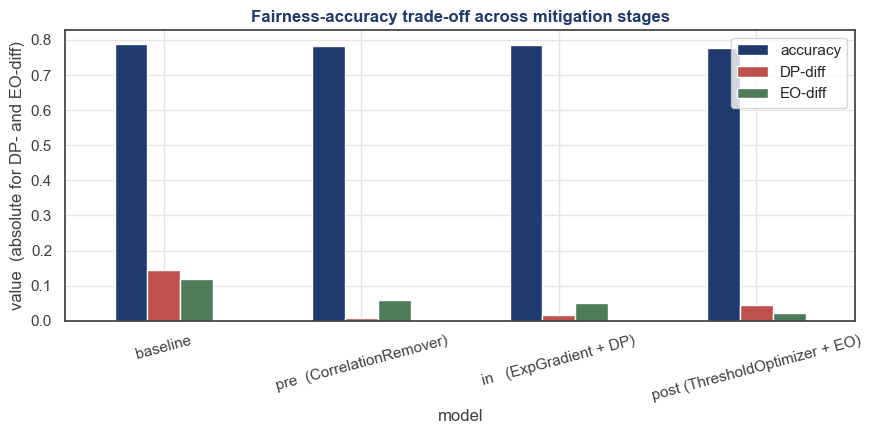

In [37]:
# A trade-off bar chart: accuracy vs DP-diff vs EO-diff for the four models.
fig, ax = plt.subplots(figsize=(9, 4.5))
fairness_table[["accuracy", "DP-diff", "EO-diff"]].abs().plot(
    kind="bar", ax=ax, color=[PRIMARY, ACCENT_RED, ACCENT_GREEN], rot=15,
)
ax.set_ylabel("value  (absolute for DP- and EO-diff)")
ax.set_title("Fairness-accuracy trade-off across mitigation stages")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fair_tradeoff.png", dpi=160, bbox_inches="tight")
plt.show()

**Reading the trade-off.** Mitigation always costs *something*. Pre-processing usually loses 1–3 points of accuracy; in-processing can sit anywhere on the Pareto frontier (you tune `eps` to choose); post-processing typically gives the smallest accuracy hit per unit of fairness, but requires group membership *at prediction time*, which is sometimes legally or operationally impossible.

### 3.6 Sidebar — fairness on freMTPL2

To bring the lesson home to insurance, we audit a quick claim-frequency classifier on freMTPL2 by **driver age band** (`DrivAge_band`) — not a legally protected attribute in most jurisdictions, but a useful surrogate that shows the same machinery applies to your day-job data.

In [38]:
# Quick frequency classifier on freMTPL2 by age band.
fre_small = fre_small.copy()
fre_small["DrivAge_band"] = pd.cut(fre_small["DrivAge"], bins=[17, 30, 45, 65, 100],
                                   labels=["18-30", "31-45", "46-65", "65+"])

fre_X = fre_small[FEATURES_NUM + FEATURES_CAT].copy()
fre_X["Density"] = np.log1p(fre_X["Density"])
fre_y = fre_small["had_claim"].astype(int).values
fre_A = fre_small["DrivAge_band"]

Xf_tr, Xf_te, yf_tr, yf_te, Af_tr, Af_te = train_test_split(
    fre_X, fre_y, fre_A, test_size=0.30, random_state=SEED, stratify=fre_y
)
fre_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf",        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)),
]).fit(Xf_tr, yf_tr)
pf = fre_pipe.predict_proba(Xf_te)[:, 1]
yf_hat = (pf >= 0.5).astype(int)

mf_fre = MetricFrame(
    metrics=metrics, y_true=yf_te, y_pred=yf_hat, sensitive_features=Af_te,
)
print("freMTPL2 — group-wise metrics by driver age band:")
print(mf_fre.by_group.round(3))
print()
print(f"DP-diff: {demographic_parity_difference(yf_te, yf_hat, sensitive_features=Af_te):.3f}")
print(f"EO-diff: {equalized_odds_difference   (yf_te, yf_hat, sensitive_features=Af_te):.3f}")

freMTPL2 — group-wise metrics by driver age band:
              selection_rate    TPR    FPR  accuracy
DrivAge_band                                        
18-30                  0.478  0.652  0.469     0.537
31-45                  0.316  0.524  0.307     0.686
46-65                  0.421  0.556  0.414     0.585
65+                    0.650  0.777  0.640     0.392

DP-diff: 0.334
EO-diff: 0.333


**Reading the insurance angle.** Young drivers (18–30) have higher empirical claim frequency on this dataset — a *real* risk difference. A class-weighted classifier flags them more often, and our DP- and EO-diff numbers are non-trivial. The actuarial question is *not* "is this unfair" but "is this difference *risk-based* or *protected-attribute-correlated*?" The first is permissible and often required; the second is illegal in many jurisdictions and ethically contentious in most others. The metrics give you a number; the *interpretation* of that number is policy, not statistics.

### Exercise 3 — Pick a metric, pick a mitigation

Pick one mitigation technique (pre, in, or post) and one fairness metric (DP, EO, or calibration). Apply the technique with the goal of bringing your chosen metric below 0.05, and report:

1. The fairness metric before and after.
2. The accuracy before and after.
3. Whether you would deploy the mitigated model. Defend in one sentence.

> **Tip.** Pre-processing rarely shrinks DP-diff to zero on real data — the protected attribute leaks through correlated features. If you need a strict guarantee, post-processing with group-specific thresholds is the easiest path. If you cannot use group membership at prediction time, in-processing with the right constraint is your only option.

In [39]:
# Exercise 3 starter — DP-diff target with ExponentiatedGradient
ex_eg = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    constraints=DemographicParity(),
    eps=0.01,         # tighter than the demo above
)
ex_eg.fit(X_tr_s, y_acs_tr, sensitive_features=A_acs_tr["SEX_label"])
ex_yhat = ex_eg.predict(X_te_s)

ex_dp  = demographic_parity_difference(y_acs_te, ex_yhat, sensitive_features=A_acs_te["SEX_label"])
ex_acc = (ex_yhat == y_acs_te.values).mean()
print(f"DP-diff after mitigation: {ex_dp:+.4f}")
print(f"Accuracy:                 {ex_acc:.4f}")
print(f"Baseline DP-diff:         {demographic_parity_difference(y_acs_te, yhat_acs, sensitive_features=A_acs_te['SEX_label']):+.4f}")
print(f"Baseline accuracy:        {(yhat_acs == y_acs_te.values).mean():.4f}")

DP-diff after mitigation: +0.0191
Accuracy:                 0.7852
Baseline DP-diff:         +0.1449
Baseline accuracy:        0.7875


In [ ]:
# Solution — defending the deploy / no-deploy call
# Read the before/after numbers the starter printed and compute the deltas:
baseline_dp  = demographic_parity_difference(y_acs_te, yhat_acs, sensitive_features=A_acs_te["SEX_label"])
baseline_acc = (yhat_acs == y_acs_te.values).mean()
delta_dp  = ex_dp  - baseline_dp
delta_acc = ex_acc - baseline_acc
print(f"DP-diff change:    {delta_dp:+.4f}  (negative = fairer)")
print(f"Accuracy change:   {delta_acc:+.4f}  (negative = worse)")
print()
print("Deploy if AND only if:")
print("  1. The DP-diff target (< 0.05) is hit on this and on production data.")
print("  2. The accuracy loss is acceptable in the business case (often < 1 pp).")
print("  3. The remaining DP-diff survives legal / regulatory review.")
print("If any of (1)-(3) fails: iterate with a different family (pre/in/post) or constraint level.")

### 3.7 Caveats — statistical fairness is necessary, not sufficient

- **Statistical fairness ≠ legal fairness ≠ ethical fairness.** A model can pass every Fairlearn metric and still violate anti-discrimination law (it may use a forbidden proxy) or be ethically troubling (it may automate historical exclusion). Audits are a *step*, not an *answer*.
- **Group fairness ignores individuals.** Demographic parity equalises group-level rates; it says nothing about whether *any specific person* was treated fairly.
- **Insurance is a special case.** *Actuarial fairness* — pricing each policy by its true expected loss — actively *creates* group-level disparity when group risk profiles differ. Lindholm et al. (2022) propose "discrimination-free insurance pricing", which removes the protected attribute *and its causal effect* but keeps risk-based pricing on the residual. This is a different objective from any of the metrics in this notebook and worth a separate conversation.
- **The EU AI Act** classifies life and health insurance pricing as high-risk; **GDPR Article 22** restricts purely automated individual decisions. Compliance involves data-protection assessments and human oversight; statistical fairness audits feed those processes but do not replace them.

### Recap — Goal 3

You now know the canonical group-fairness metrics (demographic parity, equalized odds, calibration within groups), the impossibility result that stops you from satisfying all of them simultaneously, and the pre/in/post mitigation pattern. You have audited a real classifier with Fairlearn's `MetricFrame` and applied one technique from each mitigation stage on Folktables ACSIncome, and you have replayed the same audit on freMTPL2 to land the actuarial angle.

## Summary

A compact map of the three subtopics back to the four learning goals:

- **Goal 1 — Imbalanced classification.** Evaluate with PR-AUC, F1, MCC, balanced accuracy. Fix with SMOTE-family resampling, class weights, or both. Tune the decision threshold deliberately on the metric you care about. Recalibrate if you need probabilities and you resampled. *Demonstrated in Section 1 on freMTPL2.*
- **Goal 2 — CNNs.** Convolutions + pooling + parameter sharing turn a pixel grid into a class probability with orders of magnitude fewer parameters than a fully-connected net. Transfer learning from a pretrained backbone (EfficientNet-B0) almost always beats training from scratch on a few thousand images. *Demonstrated in Section 2 on CIFAR-10 (with optional Roboflow car-damage override).*
- **Goal 3 — XAI on a CNN.** Grad-CAM produces a heatmap over the input image showing which pixels drove the predicted class. Use it on misclassified examples to find out *why* the model is wrong. *Demonstrated in Section 2 Exercise on MNIST.*
- **Goal 4 — Fairness in ML.** Demographic parity / equalized odds / calibration within groups disagree by construction. Audit with Fairlearn's `MetricFrame`; mitigate with one pick from {pre, in, post}-processing; report the fairness-accuracy trade-off honestly. *Demonstrated in Section 3 on Folktables ACSIncome with a freMTPL2 sidebar.*

## Next steps

Continue with [Section 5 — Working with Generative AI: Basics and Best Practices](../05_genai_basics_best_practices/05_genai_basics_best_practices.ipynb), where the seminar pivots from classical and modern ML to the generative-AI half of the curriculum.

## References

**Imbalanced classification**

- Chawla, Bowyer, Hall, Kegelmeyer, *SMOTE: Synthetic Minority Over-sampling Technique*, JAIR 2002 — [arxiv.org/abs/1106.1813](https://arxiv.org/abs/1106.1813).
- Lin, Goyal, Girshick, He, Dollár, *Focal Loss for Dense Object Detection*, ICCV 2017 — [arxiv.org/abs/1708.02002](https://arxiv.org/abs/1708.02002).
- Lemaître, Nogueira, Aridas, *imbalanced-learn*, JMLR 2017 — [imbalanced-learn.org](https://imbalanced-learn.org/stable/).
- freMTPL2 via OpenML `freMTPL2freq` — mirror of the R `CASdatasets` package [github.com/dutangc/CASdatasets](https://github.com/dutangc/CASdatasets).

**CNNs and Grad-CAM**

- LeCun, Bottou, Bengio, Haffner, *Gradient-Based Learning Applied to Document Recognition*, Proc. IEEE 1998 — the canonical MNIST + CNN paper.
- Tan & Le, *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks*, ICML 2019 — [arxiv.org/abs/1905.11946](https://arxiv.org/abs/1905.11946).
- Selvaraju et al., *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization*, ICCV 2017 — [arxiv.org/abs/1610.02391](https://arxiv.org/abs/1610.02391).
- Roboflow Universe, *car-damage-detection-cpccb* (CC BY 4.0) — [universe.roboflow.com/btp-w9pyz/car-damage-detection-cpccb](https://universe.roboflow.com/btp-w9pyz/car-damage-detection-cpccb).

**Fairness**

- Chouldechova, *Fair Prediction with Disparate Impact*, Big Data 2017 — [arxiv.org/abs/1610.07524](https://arxiv.org/abs/1610.07524).
- Kleinberg, Mullainathan, Raghavan, *Inherent Trade-Offs in the Fair Determination of Risk Scores*, ITCS 2017 — [arxiv.org/abs/1609.05807](https://arxiv.org/abs/1609.05807).
- Hardt, Price, Srebro, *Equality of Opportunity in Supervised Learning*, NeurIPS 2016 — [arxiv.org/abs/1610.02413](https://arxiv.org/abs/1610.02413).
- Agarwal, Beygelzimer, Dudík, Langford, Wallach, *A Reductions Approach to Fair Classification*, ICML 2018 — [proceedings.mlr.press/v80/agarwal18a](https://proceedings.mlr.press/v80/agarwal18a/agarwal18a.pdf).
- Ding, Hardt, Miller, Schmidt, *Retiring Adult: New Datasets for Fair Machine Learning*, NeurIPS 2021 — [arxiv.org/abs/2108.04884](https://arxiv.org/abs/2108.04884).
- Lindholm, Richman, Tsanakas, Wüthrich, *Discrimination-Free Insurance Pricing*, ASTIN Bulletin 2022 — [link.springer.com/article/10.1007/s13385-022-00314-4](https://link.springer.com/article/10.1007/s13385-022-00314-4).
- Bird, Dudík, Edgar, Horn, Lutz, Milan, Sameki, Wallach, Walker, *Fairlearn: A toolkit for assessing and improving fairness in AI*, Microsoft Research, 2020 — [github.com/fairlearn/fairlearn](https://github.com/fairlearn/fairlearn).

---

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger. Code under the MIT License — see [LICENSE](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).